# Séance 3 (Notebook A) : Structures de données dynamiques
# Listes chaînées, Piles, Files, Récursion

**Enseignant :** Jean Delpech

**Cours :** Algorithmie et développement dans l'ingénierie des données

**Classe :** M1 Data

**Année scolaire :** 2025/2026

**Dernière mise à jour :** juin 2026

## Objectifs

- Comprendre les structures de données dynamiques et leur gestion mémoire
- Maîtriser les structures fondamentales : liste chaînée (simple et double), pile (stack), file (queue)
- Relier ces structures aux systèmes data concrets (pipelines, fenêtres glissantes, messaging)
- Comprendre la récursion : call stack, risque de stack overflow, mémoïsation avec `functools.lru_cache`

## Plan

| # | Partie |
|---|---|
| 1 | Modèle mémoire et structures dynamiques |
| 2 | Listes chaînées : théorie et implémentation |
| 3 | Piles (Stack) |
| 4 | Files (Queue) et modèle producteur/consommateur |
| 5 | Récursion, mémoïsation et call stack |
| 6 | Application data : fenêtre glissante et mini-projet pipeline |

> **Notebooks complémentaires de cette séance**  
> - **Notebook B** : Arbres binaires et BST  
> - **Notebook C** : Tas binaire (Heap) et files de priorité


# PARTIE 1 : Modèle mémoire et structures dynamiques

## 1.1 Structures statiques vs dynamiques

En séance 1, on a vu que le tableau numpy (`ndarray`) est une structure **statique** : sa taille est fixée à la création, les éléments sont contigus en mémoire.

Dans cette séance nous allons traiter de structures **dynamiques** qui ont une taille variable. Elles s'adaptent au fur et à mesure des insertions et suppressions, au prix d'une organisation mémoire différente.

En réalité on peut définir trois types de structures si on veut aller plus loin dans les détails :

* les **tableaux statiques** (`numpy.ndarray`) : leur taille est fixée à la création, leurs éléemnts sont stockés de manière contiguë en mémoire, il n‘y a pas de redimensionnement possible
* les **tableaux dynamiques** (`list` Python, `ArrayList` en Java, `std::vector` en C++) : leur taille est variable en apparence, mais en interne c'est toujours un bloc contigu stocké en mémoire. Quand la capacité est dépassée, Python alloue un nouveau bloc plus grand (généralement ×2), copie tous les éléments → coût O(n) occasionnel, O(1) amorti sur le long terme. L'accès par indice reste O(1). Ces deux premiers cas  sont donc équivalents.
* enfin les **structures chaînées** (liste chaînée, arbre…) : la mémoire réservée est fragmentée (chaque élément pouvant être stocké à un emplacement « déconnecté » des  autres), chaque nœud voit un emplacement mémoire alloué indépendamment, l’ajout d’un élément ne conduit pas à réaliser un copie au redimensionnement, mais alors l’accès par indice est en O(n).


| Critère | Tableau (statique) | Structure dynamique |
|---|---|---|
| Taille | Fixée à la création | Variable |
| Mémoire | Contiguë | Fragmentée (pointeurs) |
| Accès par indice | O(1) | O(n) pour liste chaînée |
| Insertion en tête | O(n) (décalage) | **O(1)** pour liste chaînée |
| Insertion en milieu | O(n) | O(1) si pointeur disponible |

**La question cruciale quand on développe :** quand préférer une structure dynamique à un tableau ?  
→ Quand on **ne connaît pas la taille à l'avance**, ou quand on insère/supprime **fréquemment en tête ou milieu**.

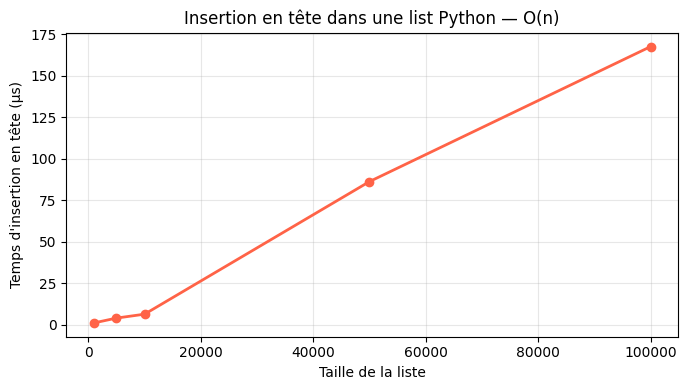

In [2]:
# Illustration : insertion en tête (list Python vs liste chaînée)
import timeit
import matplotlib.pyplot as plt

sizes = [1_000, 5_000, 10_000, 50_000, 100_000]
times_list_insert = []

for n in sizes:
    lst = list(range(n))
    t = timeit.timeit(lambda: lst.insert(0, -1), number=500) / 500
    times_list_insert.append(t * 1e6)  # µs

plt.figure(figsize=(7, 4))
plt.plot(sizes, times_list_insert, 'o-', color='tomato', linewidth=2)
plt.xlabel('Taille de la liste')
plt.ylabel('Temps d\'insertion en tête (µs)')
plt.title('Insertion en tête dans une list Python - O(n)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Onconstate que le temps d’exécution pour insérer un  élément en tête croît linéairement avec la taille de la liste, c’est à dire qu’une insertion en tête coûte O(n) pour une `list` en Python.

Voyons voir comment une structure dynamique comme les listes chaînées permettent de résoudre ce problème.

# PARTIE 2 : Listes chaînées

## 2.1 Principe

Une **liste chaînée** est une séquence de **nœuds**. Chaque nœud contient :
- une **valeur** (la donnée)
- un **pointeur** vers le nœud suivant

![Schéma liste chaînée](./Images/ListeChainee2.png)

### Complexités des opérations

De par cette structure distribuée ou fragmentée, la complexité des opération peut varier selon que l’on possède l’indice (le numéro d’ordre dans l’ensemble d’élément) de l’élément sur lequel on veut opérer, ou plutôt un pointeur vers cet élément.

| Opération | Complexité | Commentaire |
|---|---|---|
| Insertion en tête | O(1) | On relie juste le nouveau nœud à l'ancienne tête |
| Insertion en queue | O(n)  | Pour atteindre le dernier élément, il faut parcourir tous les précédents. Néanmoins on peut prévoir de disposer d’un pointeur « *tail* » qui donne un accès direct au dernier emplacement. O(1) dans  ce cas.
| Recherche | O(n) | Parcours séquentiel obligatoire jusqu’à trouver l’élément cherché |
| Suppression (avec pointeur) | O(1) | Il faut penser à modifier le pointeur du prédécesseur sinon on brise la chaîne |
| Accès par indice | O(n) | Pas d'accès direct, il faut parcourir tous les éléments précédents l’élément auquel on veut accéder |

### Liste doublement chaînée

Dans l’exemple précédent, on ne peut parcourir la liste que dans un seul  sens : arrivé à un élément *i*, on ne dispose pas du pointeur qui nous permettrait de retourner vers le prédecesseur, on ne dispose que du pointeur qui nous envoie à l’élément suivant.

Pour  résoudre ce problème, dans une liste doublement chaînée, chaque nœud possède un pointeur vers le suivant **et** vers le précédent. Cela permet la suppression et l'insertion en O(1) si on possède le pointeur vers le nœud concerné.

![Schéma liste doublement chaînée](./Images/ListeDoublementChainee.png)

## 2.2 Implémentation : Liste simplement chaînée (avec tail)

Une liste simplement chaînée repose sur deux classes distinctes : le nœud (qu’on  va appeler `Node`) et la liste elle-même (`SinglyLinkedList`).

### `Node` (le nœud)

C'est la brique de base. Chaque nœud porte deux attributs : `value` (la donnée stockée) et `next` (une référence vers le nœud suivant, ou `None` si c'est le dernier). On n’a  besoin d’aucun autre attribut, car un nœud n'a aucune connaissance de la liste qui le contient. Il ne fait qu’un chose très bête : donner sa valeur ou dire où se trouve l’élément suivant.

### `SinglyLinkedList` (la liste elle-même)

Paradoxalement, cette liste (avec `tail`) ingore aussi plein de choses, car elle ne stocke pas les éléments directement. Elle ne connaît que deux points d'entrée dans la chaîne. On peut aussi penser à noter le nombre d’éléments stockés dans la liste :

- `head` : référence vers le premier nœud (ou `None` si la liste est vide)
- `tail` : référence vers le dernier nœud, maintenu pour permettre l'insertion en queue en O(1) sans parcourir toute la chaîne
- `size` : compteur entier, incrémenté/décrémenté à chaque modification

### les opérations

Maintenant qu’on a une liste, il faut lister les opérations que l’on veut réaliser dessus :

- **ajouter un élément en tête** : `prepend(value)`
  crée un nouveau nœud, fait pointer son `next` vers l'actuel `head`, puis déplace `head` sur ce nouveau nœud. Si la liste était vide, `tail` pointe aussi sur ce nœud. Complexité : O(1).
- **ajouter un élément en queue** : `append(value)`
  crée un nouveau nœud, fait pointer le `next` de l'actuel `tail` vers lui, puis déplace `tail`. Si la liste était vide, `head` et `tail` pointent tous les deux sur ce nœud. Complexité : O(1).
- **rechercher** un élément : `search(value)`
  part de `head` et avance de nœud en nœud via `next` jusqu'à trouver la valeur ou atteindre `None`. Complexité : O(n) dans le pire cas (l’élément cherché est à la fin de la liste).
- **supprimer** un élément : `delete(value)̀`
  Ici on va devoir gérer des situations un peu complexes, car on ne peut pas reculer dans une liste simplement chaînée. Ainsi :
  - si on supprime la valeur en tête, il suffit de déplacer `head` au nœud suivant, qui devient la nouvelle tête
  - sinon on parcourt la liste en mémorisant le pointeur vers le nœud précédent et quand on arrive sur le nœud à supprimer on fait simplement pointer le nœud qui précéde (le nœud à supprimer) vers le nœud qui suit (le nœud à supprimer). Idem, on parcours la liste donc la complixité est : O(n).
- une fonction pour **itérer** sur la liste (la parcourir). On va ici utiliser un mot clef très spécifique à Python : `yield` qui transforme une fonction en *générateur* (on parle de fonction génératrice). Une fonction « ordinaire » renvoie une valeur avec `return` et c’est finit, elle est exécutée. Quand on va la rappeler, elle va se lancer comme si c’était la première fois qu’elle était appelée. Une fonction génératrice va s’exécuter jusqu’à rencontrer `yield`, et là elle va interrompre son exécution et renvoyer la valeur. Lorsqu’elle va être rappelée, elle va alors reprendre dans l’état où elle s’est arrêtée lors de l’appel précédent. On va appele une telle fonction avec une boucle `for` ou avec `next()`. [Allez voir ici des exemples très parlant](https://www.w3schools.com/python/ref_keyword_yield.asp) de comment cela fonctionne (je ne les intégre pas ici pour ne pas alourdir).
  pour itérer dans la liste on va donc créer une fonction génératrice `__iter__` qui nous permettra en utilisant la propriété de `yield` d’avancer « pas à pas » (ou « nœud après nœud ») dans la liste, à cahque appel de ̀`__iter__`

L’implémentation n’est pas bien compliquée (sauf pour `__iter__`) mais on se confronte vite à des cas limites :
- liste vide
- insertion/suppression en tête/queue

Ce sont souvent des implémentations naïves à ce niveau qui plantent.

In [3]:
class Node:
    """Un nœud d'une liste simplement chaînée."""

    def __init__(self, value):
        self.value = value
        self.next = None  # pointeur vers le nœud suivant

    def __repr__(self):
        return f"Node({self.value!r})"


class SinglyLinkedList:
    """Liste simplement chaînée."""

    def __init__(self):
        self.head = None  # premier nœud
        self.tail = None  # dernier nœud (pour insertion en queue O(1))
        self.size = 0

    # ── Insertion ──────────────────────────────────────────────────

    def prepend(self, value):
        """Insère en tête. O(1)."""
        node = Node(value)
        node.next = self.head
        self.head = node
        if self.tail is None:   # liste était vide
            self.tail = node
        self.size += 1

    def append(self, value):
        """Insère en queue. O(1) grâce au pointeur tail."""
        node = Node(value)
        if self.tail is None:   # liste vide
            self.head = self.tail = node
        else:
            self.tail.next = node
            self.tail = node
        self.size += 1

    # ── Recherche ──────────────────────────────────────────────────

    def find(self, value):
        """Recherche un nœud par valeur. O(n)."""
        current = self.head
        while current:
            if current.value == value:
                return current
            current = current.next
        return None

    # ── Suppression ────────────────────────────────────────────────

    def remove(self, value):
        """Supprime la première occurrence d'une valeur. O(n)."""
        current = self.head
        previous = None
        while current:
            if current.value == value:
                if previous:
                    previous.next = current.next   # court-circuit
                else:
                    self.head = current.next        # suppression de la tête
                if current == self.tail:
                    self.tail = previous            # mise à jour tail
                self.size -= 1
                return True
            previous, current = current, current.next
        return False

    # ── Utilitaires ────────────────────────────────────────────────

    def to_list(self):
        """Convertit en liste Python pour l'affichage. O(n)."""
        result, current = [], self.head
        while current:
            result.append(current.value)
            current = current.next
        return result

    def __len__(self):
        return self.size

    def __repr__(self):
        return " → ".join(str(v) for v in self.to_list()) + " → None"


# ── Démonstration ──────────────────────────────────────────────────
ll = SinglyLinkedList()
for val in ['C', 'B', 'A']:
    ll.prepend(val)
print(f"Après 3 prepend : {ll}")

ll.append('D')
print(f"Après append D  : {ll}")

ll.remove('B')
print(f"Après remove B  : {ll}")

print(f"Taille          : {len(ll)}")
print(f"Find 'C'        : {ll.find('C')}")
print(f"Find 'Z'        : {ll.find('Z')}")

Après 3 prepend : A → B → C → None
Après append D  : A → B → C → D → None
Après remove B  : A → C → D → None
Taille          : 3
Find 'C'        : Node('C')
Find 'Z'        : None


Deux (et même trois) remarques sur cette implémentation, une importante, l’autre plus abstraite.

1. On remarque ici que chercher un nœud c’est en fait chercher une valeur (on désigne un nœud par la valeur qu’il contient). Cela crée une ambiguïté : que faire si plusieurs nœuds contiennent la même valeur ? Il faut définir notre méthode `search` : doit-elle retourner toute les valeurs ou seulement la première trouvée ? on peut aussi définir une fonction `search_all`. De même pour la suppression (`delete_all`). On peut aussi indiquer qu’on doit interdire les doublons et vérifier qu’une valeur n’existe pas déjà avant de la `prepend`/`append`. Il n‘y a pas de choix meilleur qu’un autre, tout dépend du cas d’usage, mais il faut bien y penser.
2. Cela vient du fait qu’en réalité, l’identité d’un nœud, ce n’est pas sa valeur (comme nous avons fait ici), mais plutôt sa position dans la chaîne ou sa référence en mémoire (pointeur). On verra que c’est un problème qu’on appréhende mieux avec une liste doublement chaînée.
> Ici une troisième remarque sur l’implémentation en Python. Si on avait réalisé cette implémentation en C, on aurait utilisé des pointeurs qui ne sont rien d’autre que des valeurs entières qui désigne un emplacement précis en mémoire (une adresse). En Python – je l’ai déjà rappelé dans un cours précédent – on manipule des références, qui réalisent un lien entre un nom (de variable) et un objet en mémoire. Ce mécanisme nous permet d’écrire directement et très simplement `node.next = autre_noeud`, car ainsi on stocke une référence vers l’objet `autre_noeud` dans l’attribut `node.next` et c’est l’interpréteur Python qui va gérer le pointage référene/adresses vers l’objet voulu. Dans d’autres langages une telle affectation réaliserait juse une copie de la valeur de l’objet, ce qui ne fonctionnerait pas pour créer une liste chaînée. Attention donc si vous voulez transposer ce code dans un autre langage.

## 2.3 Implémentation : Liste doublement chaînée

L’implémentation de listes doublements chaînées apporte son lot de subtilités, car elle simplifie certaines opérations décrites ci-dessous, mais cela demande de prendre quelques dispositions pour éviter à avoir à tester trop de cas limites. 

### `insert_between` 

Dans une liste doublement chaînée, on peut facilement créer une fonction `insert_between` qui permet d’insérer un élément entre deux éléments déjà stockés dans la liste.

> Remarque importante : même si nous ne l’avons pas implémenté précédemment, on pourrait créer une méthode `insert_between` pour une liste simple, mais il faudrait alors récupérer une information dont on ne dispose pas au niveau d’un nœud : la référence vers le nœud précédent (pour « créer » une place entre deux nœuds qui se suivent). C’est un peu le même genre de problème que nous avons pu évoquer pour la suppression.

Cette insertion est facilité par le fait que chaque nœud dispose de deux références (vers le nœud suivant et le nœud précédent), ce qui fait que l’insertion au milieu de la liste nécessite de mettre à jour 4 références : les deux références de l’élément inséré – qui pointera vers les éléments qui étaient côté à côte dont l’un deviendra l’élément précédent et l’autre l’élément suivant –, et une référence de l’élement précédent dont le successeur sera désormais l’élément nouvellement inséré, et de l’élément suivant dont le prédécesseur deviendra l’élément nouveau. Une illustration simplifie beaucoup ce qui est dur à décrire en mots :

![Schéma insert_between](./Images/insert_between.png)

Il faut surtout prendre garde à modifier ces pointeurs dans le bon ordre. En effet, les deux premiers pointeurs à mettre à jour sont ceux  de l’élément qu’on insère : il faut qu’ils pointent vers l’élément qui deviendra le précédent, et vers l’élément qui deviendra le suivant, dont on va récupérer les références. Ensuite seulement on pourra mettre à jours leurs propres références vers le nouvel élément. 

```
1. node.prev ← before
2. node.next ← after
3. before.next ← node
4. after.prev ← node
```

Si on procède dans le sens inverse (d’abord écrire les références vers le nouvel objet dans les éléments prédécesseur/successeur) on va écraser les références des objets déjà présent (si on ne les a pas sauvegardé avant) et on perd l’information qui rend l’insertion possible.

### les « sentinelles »

Pour les listes simples, on avait des fonctions spéciales pour insérer des éléments en tête ou en queue de liste. Ici, on poourrait réutiliser pour ce faire la même fonction `insert_between`, au pris d’une petite astuce.

En effet quand on est en bout de liste (tête ou queue) ou quand on est dans une liste vide (donc quand on est à la fois en tête et en queue) il faudrait faire des tests spécifiques pour identifier dans quelle configuration on se trouve pour mettre à jour les bons pointeurs/références (modifier un élément qui n’existe pas – aucun prédesseur pour la tête de lise p. ex. – renverrait une erreur si on ne vérifie pas).

Avec une astuce on peut nettement simplifier le traitement de ces cas particuliers.

On va simplement créer des « sentinelles » c’est à dire des nœuds placés en tête et en queue de liste qui ne vont contenir aucune valeur (`Node.value = None`) mais qui existent tout de même (des sortes de nœuds virtuels). 

![Schéma sentinelles](./Images/Sentinelles.png)

Ces nœuds vont en permanence borner la liste en « sandwich » ce qui fait que :
- la liste ne sera jamais vide
- on ne sera jamais en tête ou en queue de liste
- toute insertion se fera avec `insert_between` qui n’aura pas à tester dans quelle configuration elle se trouve
- insérer en « tête » (`append_left`) ou « queue » de liste (`append_right`) consistent juste en un `insert_between` après ou avant les sentinelles
- ces opérations sont symétriques (il suffit de modifier l’ordre des arguements pour ajouter à gauche ou à droite)

### Suppression

La suppression est très simple dans le sens où on n’a plus besoin de parcourir la liste pour connaître le prédesseur à mettre à jour : on dispose immédiatement d’un pointeur vers celui-ci, donc on peut opérer complètement localement sans connaître le reste de la liste. On a juste deux poiniteurs à mettre à jour, d’où la complexité de cette opération qui devient toujours O(1).

```
1. node.prev.next ← node.next
2. node.next.prev ← node.prev
```

En appelant cette fonction de suppression ainsi définie, on peut créer des fonctions `pop_left` et `pop_right` qui suppriment les éléments en début et fin de liste (attention à tester si la liste est vide ou pas, pour ne pas supprimer les sentinnelles par inadvertance).

In [ ]:
class DNode:
    """Nœud d'une liste doublement chaînée."""

    def __init__(self, value):
        self.value = value
        self.prev = None
        self.next = None


class DoublyLinkedList:
    """Liste doublement chaînée."""

    def __init__(self):
        # Sentinelles : nœuds fictifs en tête et en queue
        # Évite les cas limites (liste vide, suppression de tête/queue)
        self._head = DNode(None)  # sentinelle gauche
        self._tail = DNode(None)  # sentinelle droite
        self._head.next = self._tail
        self._tail.prev = self._head
        self.size = 0

    def _insert_between(self, value, before: DNode, after: DNode):
        """Insère un nouveau nœud entre before et after. O(1)."""
        node = DNode(value)
        node.prev, node.next = before, after
        before.next = after.prev = node
        self.size += 1
        return node

    def _delete_node(self, node: DNode):
        """Supprime un nœud connu. O(1)."""
        node.prev.next = node.next
        node.next.prev = node.prev
        self.size -= 1

    def append_left(self, value):
        """Insère en tête. O(1)."""
        return self._insert_between(value, self._head, self._head.next)

    def append_right(self, value):
        """Insère en queue. O(1)."""
        return self._insert_between(value, self._tail.prev, self._tail)

    def pop_left(self):
        """Supprime et retourne la valeur de tête. O(1)."""
        if self.size == 0:
            raise IndexError("pop_left sur liste vide")
        node = self._head.next
        self._delete_node(node)
        return node.value

    def pop_right(self):
        """Supprime et retourne la valeur de queue. O(1)."""
        if self.size == 0:
            raise IndexError("pop_right sur liste vide")
        node = self._tail.prev
        self._delete_node(node)
        return node.value

    def to_list(self):
        result, current = [], self._head.next
        while current is not self._tail:
            result.append(current.value)
            current = current.next
        return result

    def __len__(self):
        return self.size

    def __repr__(self):
        return "None ↔ " + " ↔ ".join(str(v) for v in self.to_list()) + " ↔ None"


# ── Démonstration ──────────────────────────────────────────────────
dll = DoublyLinkedList()
dll.append_right('B')
dll.append_right('C')
dll.append_left('A')
print(f"Liste           : {dll}")

v = dll.pop_left()
print(f"pop_left()  = {v!r}  →  {dll}")

v = dll.pop_right()
print(f"pop_right() = {v!r}  →  {dll}")

## 2.4 Exercice : Détecter un cycle dans une liste chaînée

### Contexte

Un bug classique en data engineering : une liste chaînée corrompue contient un cycle (un nœud dont le pointeur next pointe vers un nœud déjà visité en amont dans la chaîne). Parcourir une telle liste avec une boucle `while current is not None` produit une boucle infinie, puisqu'on n'atteindra jamais `None` (la valeur de la sentinelle de fin (`queue` ou  `tail`).

```
A → B → C → D → E
        ↑       |
        └── F ──┘
```

Ici `F.next` pointe vers `C` : la liste ne se termine jamais.

On peut essayer de résoudre ce problème de manière naïve :

1. La première idée est de mémoriser tous les nœuds visités dans un ensemble (`set`), et de vérifier à chaque pas si le nœud courant a déjà été vu. Ça fonctionne, mais ça coûte O(n) en mémoire supplémentaire car on stocke une référence vers chaque nœud visité.
2. La deuxième idée est de compter les pas et de s'arrêter au bout d'un certain nombre d'itérations. Ça ne fonctionne pas : on ne connaît pas la longueur de la liste à l'avance, et un cycle peut être très long.

Un algorithme très efficace qui repose sur une idée très simple permet de résoudre ce problème : l’algorithme de Floyd.

### Algorithme de Floyd (lièvre et tortue) 

L'algorithme de Floyd résout le problème en O(n) temps et O(1) espace, c’est-à-dire sans mobiliser aucune mémoire supplémentaire.
Le principe est très simple : faire avancer deux pointeurs simultanément depuis `head`, à des vitesses différentes.

- Le pointeur « tortue » (`slow`) avance d'un nœud à chaque pas
- Le pointur « lièvre » (`fast`) avance de deux nœuds à chaque pas

Dans cette configuration, on finit par arriver sur deux situations différentes :

- S'il n'y a pas de cycle (le circuit est ouvert / rectiligne), le lièvre atteindra `None` (ou l'avant-dernier nœud) en premier, vu qu’il est le plus rapide, ce qui signifie que la la boucle se termine naturellement.
- S'il y a un cycle (le circuit est fermé, la liste boucle sur elle-même), le lièvre et la tortue vont tous les deux tourner indéfiniment dans ce cycle. Et comme le lièvre est plus rapide, il va rattraper la tortue par derrière à un  moment donnée, et ils finiront inévitablement sur le même nœud au bout d’un certain temps.
Imaginez un lièvre et une tortue qui font la course sur une piste circulaire. Le plus rapide finira toujours par doubler le plus lent et se retrouver à sa hauteur (sinon imaginez une piste d’athlétisme ou un circuit de F1). Si la piste est un segment rectiligne avec une arrivée (pas de cycle), le plus rapide atteint la fin sans jamais croiser le plus lent.

```
Pas 0 :   tortue = A,  lièvre = A
Pas 1 :   tortue = B,  lièvre = C
Pas 2 :   tortue = C,  lièvre = E
Pas 3 :   tortue = D,  lièvre = D  ← rencontre → cycle détecté
```

Plus formellement : une fois que les deux pointeurs sont entrés dans le cycle, le lièvre gagne un nœud d'avance sur la tortue à chaque pas. La distance entre eux diminue donc de 1 à chaque itération. Si le cycle a une longueur L, ils se rejoignent au bout de L pas au plus.

> À titre d’exercice, implémenter `has_cycle(head)` en utilisant l'algorithme de Floyd. Complexité attendue : O(n) temps, O(1) espace.
> (Ça doit tenir dans une boucle `while` de cinq lignes)

In [ ]:
def has_cycle(head: Node) -> bool:
    """
    Détecte si une liste chaînée contient un cycle.
    Algorithme de Floyd : tortue (×1) et lièvre (×2).
    Complexité : O(n) temps, O(1) espace.
    """
    # TODO : implémenter
    # Indice : slow avance d'un pas, fast de deux pas
    # S'ils se rencontrent → cycle
    pass


# ── Tests ──────────────────────────────────────────────────────────

# Liste sans cycle : A → B → C → None
n1, n2, n3 = Node('A'), Node('B'), Node('C')
n1.next, n2.next = n2, n3
print(f"Liste sans cycle : has_cycle = {has_cycle(n1)}")  # attendu : False

# Liste avec cycle : A → B → C → B (cycle)
n3.next = n2
print(f"Liste avec cycle : has_cycle = {has_cycle(n1)}")  # attendu : True

# PARTIE 3 : Piles (Stack)

## 3.1 Principe LIFO

Une **pile** (stack) suit le principe **LIFO** : *Last In, First Out*.  
Le dernier élément inséré est le premier à être retiré, comme une pile d'assiettes :

![Schéma pile](./Images/Stack.png)

Il est d’usage d’appeler `push()` la méthode qui permet « d’empiler » un élément sur la pile, et `pop()` la méthode qui permet de « dépiler » un élément de la pile (et qui retourne cet élément). Vous avez certainement déjà utilisé ces méthodes avec d’autres objets en Python. Parfois on dispose aussi d’une méthode `peek()` qui permet de lire la valeur de l’élément au sommet de la pile sans le retirer pour autant.

```
          push(C)     push(D)     pop()        peek()
┌───┐     ┌───┐       ┌───┐      ┌───┐        ┌───┐
│ B │  →  │ C │  →    │ D │  →   │ C │  →     │ C │
│ A │     │ B │       │ C │      │ B │        │ B │
└───┘     │ A │       │ B │      │ A │        | A |
          └───┘       │ A │      └───┘        └───┘
                      └───┘   retourne D      retourne C
                              (et le «sort»)  (et le conserve)
```

### Cas d'usage

C’est vraiment une structure élémentaire, qui peut par exemple servir à implémenter des algorithme plus complexes (on verra ça dans la séance suivante sur les graphes). Voici différents usages possibles, plus ou moins élaborés :

| Cas | Comment la pile intervient |
|---|---|
| **Call stack** | Chaque appel de fonction empile un frame ; `return` le dépile |
| **Parsing** | Exemple d’usage élémentaire : vérifier que les parenthèses sont bien équilibrées |
| **Undo/Redo** | Chaque action est empilée ; undo dépile |
| **DFS (graphes)** | Parcours en profondeur (on verra ça dans la séance 4) |

### Implémentation

Voici une implémentation facile à lire et comprendre d’une classe `Stack` (pile) qui dispose des méthodes élémentaires :

In [ ]:
class Stack:
    """Pile LIFO implémentée avec une liste Python."""

    def __init__(self):
        self._data = []

    def push(self, value):
        """Empile une valeur. O(1) amorti."""
        self._data.append(value)

    def pop(self):
        """Dépile et retourne la valeur du sommet. O(1)."""
        if self.is_empty():
            raise IndexError("pop sur pile vide")
        return self._data.pop()

    def peek(self):
        """Retourne la valeur du sommet sans la retirer. O(1)."""
        if self.is_empty():
            raise IndexError("peek sur pile vide")
        return self._data[-1]

    def is_empty(self):
        return len(self._data) == 0

    def __len__(self):
        return len(self._data)

    def __repr__(self):
        return f"Stack(top={self._data[-1]!r}, size={len(self._data)})" if self._data else "Stack(vide)"


# ── Démonstration ──────────────────────────────────────────────────
s = Stack()
for item in [10, 20, 30]:
    s.push(item)
    print(f"push({item}) → {s}")

print()
while not s.is_empty():
    print(f"pop()  = {s.pop()}")

## 3.2 Exemple d’usae : Vérifier l'équilibre des parenthèses dans une requête SQL

Voici un exemple d’utilisation assez basique : vérifier qu’il n‘y a pas d’erreur de parenthèses (équilibrage) dans une requête SQL. On va empiler les parenthèses (ou crochets, ou accolades…) à chaque fois qu’on en ouvre une, et on va les dépiler dès qu’on en ferme une. Si on dépile plus ce que ce qu’on a empilé : c’est qu’on a fermé trop de parenthèses par rapport au nombre de parenthèses ouvertes, et si à la fin de la requête on a encore des parenthèses empilées (donc, ouvertes), c’est qu’on en a pas assez fermées.

In [ ]:
def check_balanced(expression: str) -> tuple[bool, str]:
    """
    Vérifie que les délimiteurs ouvrants/fermants sont équilibrés.
    Retourne (True, 'OK') ou (False, message d'erreur).
    """
    stack = Stack()
    pairs = {')': '(', ']': '[', '}': '{'}
    openers = set(pairs.values())

    for i, char in enumerate(expression):
        if char in openers:
            stack.push((char, i))
        elif char in pairs:
            if stack.is_empty():
                return False, f"Fermant '{char}' à position {i} sans ouvrant"
            top_char, top_pos = stack.pop()
            if top_char != pairs[char]:
                return False, f"'{char}' pos {i} ne correspond pas à '{top_char}' pos {top_pos}"

    if not stack.is_empty():
        char, pos = stack.pop()
        return False, f"Ouvrant '{char}' pos {pos} jamais fermé"

    return True, "OK"


requetes = [
    "SELECT * FROM t WHERE (a = 1 AND (b = 2 OR c = 3))",
    "SELECT MAX(price) FROM orders WHERE (status = 'active'",
    "WITH cte AS (SELECT id FROM t) SELECT * FROM cte WHERE id IN (1, 2)",
    "SELECT CASE WHEN (x > 0) THEN 'pos' ELSE 'neg' END FROM t",
    "SELECT *(a+b) FROM t",   # * interférence bénigne
]

for req in requetes:
    ok, msg = check_balanced(req)
    status = "✓" if ok else "✗"
    print(f"{status} {req[:55]:<55}  {'' if ok else '→ ' + msg}")

# PARTIE 4 : Files (Queue) et modèle producteur/consommateur

## 4.1 Principe FIFO

Une **file** (queue) est une autre structure qui elle suit le principe **FIFO** : *First In, First Out*.  
Le premier élément inséré (en générale avec la méthode `enqueue()`)  est le premier à être retiré (avec la méthode `dequeue()`), comme dans une file d'attente.

![Schéma file](./Images/Queue.png)

```
  enqueue(A)   enqueue(B)   enqueue(C)   dequeue()   dequeue()
  ┌───┐        ┌───┬───┐   ┌───┬───┬───┐  ┌───┬───┐   ┌───┐
  │ A │   →    │ A │ B │ → │ A │ B │ C │→ │ B │ C │→  │ C │
  └───┘        └───┴───┘   └───┴───┴───┘  └───┴───┘   └───┘
  ← in                          out →    retourne A  retourne B
```

### Cas d'usage data

Comme pour la pile, la file est une structure élémentaire. Elle est utilisée dans toutes les situations où on doit traiter les données dans l’ordre où elles arrivent (strictement), comme dans une file d’attente. Également comme pour la pile, la file peut être mise en œuvre dans des algorithme plus complexe où le traitement dans l’ordre d’arrivée est important.


| Cas | Comment la file intervient |
|---|---|
| **Pipeline de traitement de logs** | Les événements sont traités dans l'ordre d'arrivée (file d’attente)|
| **Kafka / RabbitMQ** | Systèmes de messaging = files distribuées |
| **BFS (graphes)** | Parcours en largeur (cf. séance 4 à venir) |
| **Scheduler de tâches** | Les tâches sont exécutées dans l'ordre de soumission |

## 4.2 Implémentation 

En Python on évitera d’utiliser une `list` pour implémenter une file. (bien sûr on dispose en Python déjà du typde ad hoc dans le module `collections`).

De par la manière dont les listes sont implémentées en Python, lors que l’on va ajouter (`enqueue()`) un élément à la liste (avec `append()`) tout va bien se passer, mais quand on va retirer un élément (`dequeue`), on va nécessairement retirer le premier élément inséré, c’est à dire celui à l’index 0. Donc il va falloir ensuite décaler tous les éléements d’un index pour que l’élément suivant (n°2) devienne le premier. Donc chaque `enqueue` va provoquer $n$ opérations (si $n$= nombre d’éléments dans la file/liste), ce qui n’est pas optimal.

```python
queue = []
queue.append(x)    # enqueue : on rajoute juste un élément en fin de liste, complexité : O(1) amorti
queue.pop(0)       # dequeue : on doit décaler tous les éléments ! Complexité : O(n) !!!
```

On va donc directemnt utiliser `collections.deque` (liste doublement chaînée) : `appendleft`/`append` et `pop`/`popleft` sont tous **O(1)**.

In [ ]:
# Démonstration : list.pop(0) vs deque.popleft()
import timeit
from collections import deque

sizes = [1_000, 5_000, 10_000, 50_000]

print(f"{'n':>8} | {'list.pop(0) (µs)':>18} | {'deque.popleft() (µs)':>20}")
print("-" * 55)
for n in sizes:
    t_list  = timeit.timeit(lambda: list(range(n)).pop(0),       number=200) / 200 * 1e6
    t_deque = timeit.timeit(lambda: deque(range(n)).popleft(),   number=200) / 200 * 1e6
    print(f"{n:>8,} | {t_list:>18.2f} | {t_deque:>20.2f}")

In [ ]:
from collections import deque

class Queue:
    """File FIFO implémentée avec collections.deque."""

    def __init__(self, maxsize=None):
        self._data = deque(maxlen=maxsize)  # maxlen optionnel : file bornée

    def enqueue(self, value):
        """Ajoute en queue. O(1)."""
        self._data.append(value)

    def dequeue(self):
        """Retire et retourne l'élément en tête. O(1)."""
        if self.is_empty():
            raise IndexError("dequeue sur file vide")
        return self._data.popleft()

    def peek(self):
        """Retourne l'élément en tête sans le retirer. O(1)."""
        return self._data[0]

    def is_empty(self):
        return len(self._data) == 0

    def __len__(self):
        return len(self._data)

    def __repr__(self):
        return f"Queue({list(self._data)})"


# Démonstration
q = Queue()
for item in ['tâche_1', 'tâche_2', 'tâche_3']:
    q.enqueue(item)
    print(f"enqueue({item!r}) → {q}")

print()
while not q.is_empty():
    print(f"dequeue() = {q.dequeue()!r}")

## 4.3 Modèle producteur / consommateur

C’est un concept très simple et très intuitif qui résout un problème courant.

Le modèle **producteur/consommateur** est omniprésent en data engineering :
- Un **producteur** génère des messages (logs, événements, transactions)
- Un **consommateur** les traite à son rythme (donc parfois bien moins vite que ce qu’ils sont produits).

Comment gérer cette situation ? Commme dans la vie réelle :
- La **file** (d’attente) découple les deux, le producteur n'attend pas le consommateur car les messages sont stockés « en attentdant ».

C'est le modèle exact de **Kafka** (topics = files distribuées) et **RabbitMQ**.
Que veulent dire ces deux termes techniques et abscons par rapport à un concept aussi basique que celui d’une file d’attente ?

* Une file d’attente qui sert jsute à faire tampon entre le producteur et le consommateur peut en effet être implémentée par la classe `Queue` que nous venons de créer. Néanmoins sa nature est celle d’un processus Python stocké en mémoire. On parle de traiter un volume extrêmement important de messages, vous vous doutez bien qu’il va falloir mettre en œuvre quelque chose de plus élaboré que cela !

* [**RabbitMQ**](https://www.rabbitmq.com/) est un serveur dédié qui joue le même rôle mais entre des processus ou des machines différentes, le producteur et le consommateur peuvent être deux programmes distincts, voire sur deux serveurs différents. Vous pouvez en apprendre plus sur [la fiche Wikipedia sur ce projet](https://fr.wikipedia.org/wiki/RabbitMQ) ou par exemple [cet article](https://geekflare.com/fr/rabbitmq-explained/) qui en décrit le fonctionnement de manière plus détaillée.

* **Kafka** ([projet de la Fondation Apache](https://kafka.apache.org/)) va plus loin : la file est stockée de manière persistante sur disque et peut être relue. Plusieurs consommateurs peuvent lire le même flux indépendamment, chacun à son propre rythme, sans que la lecture d'un consommateur n'efface les messages pour les autres. Idem, [voici la fiche Widipedia sur ce projet](https://fr.wikipedia.org/wiki/Apache_Kafka)



```
  Producteur          File (Kafka topic)        Consommateur
  ──────────    →→→   ┌───┬───┬───┬───┐   →→→   ────────────
  (génère vite)       │msg│msg│msg│msg│         (traite lentement)
                      └───┴───┴───┴───┘
```

In [6]:
import queue
import threading
import time
import random

# File thread-safe de la bibliothèque standard
event_queue = queue.Queue(maxsize=10)
results = []
lock = threading.Lock()

def producer(n_events: int):
    """Génère n_events messages à intervalle aléatoire."""
    event_types = ['INFO', 'WARNING', 'ERROR']
    for i in range(n_events):
        event = {
            'id': i,
            'type': random.choices(event_types, weights=[7, 2, 1])[0],
            'ts': time.time()
        }
        event_queue.put(event)           # bloque si la file est pleine
        time.sleep(random.uniform(0, 0.02))
    event_queue.put(None)                # signal de fin (poison pill)


def consumer():
    """Traite les événements de la file jusqu'au signal de fin."""
    while True:
        event = event_queue.get()
        if event is None:                # poison pill → arrêt
            break
        # Simulation d'un traitement (plus lent que la production)
        time.sleep(random.uniform(0, 0.01))
        with lock:
            results.append(event['type'])
        event_queue.task_done()


N_EVENTS = 30
t_prod = threading.Thread(target=producer, args=(N_EVENTS,))
t_cons = threading.Thread(target=consumer)

t_prod.start()
t_cons.start()
t_prod.join()
t_cons.join()

from collections import Counter
counts = Counter(results)
print(f"Événements traités : {len(results)} / {N_EVENTS}")
print(f"Distribution       : {dict(counts)}")

Événements traités : 30 / 30
Distribution       : {'INFO': 21, 'WARNING': 7, 'ERROR': 2}


### Exercice (optionnel)

À partir de l’implémentation précédente, créez une visualisation en fonction du temps :

- évolution temporelle des messages produits
- évolution temporelle de la taille de la file
- évolution temporelle du traitement des messages

In [1]:
# votre code

# PARTIE 5 : Récursion, mémoïsation et call stack

## 5.1 Le call stack et le risque de stack overflow

Chaque appel de fonction empile un **frame** sur la pile d'appels (*call stack*). Ce frame contient :
- les paramètres locaux
- l'adresse de retour (où on revient une fois la fonction exécutée)
- les variables locales

Python limite la profondeur de récursion à **~1000 appels** par défaut (ordre de grandeur). Au-delà : `RecursionError`.

Voyons un exemple avec la fameuse suite de Fibonacci :

La suite de Fibonacci est définie par la récurrence :
$$
F(n) = F(n-1) + F(n-2)
$$

Plus simplement : un terme est obtenu en faisant la somme des deux termes précédents.
Pour démarrer la suite, il faut donc diposer de deux termes que l’on doit fixer, ce sont les conditions initiales :
$$
F(0) = 0 \quad F(1) = 1
$$

Ce qui donne : 0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 89 ...

Pour implemnter cette suite, il suffit de créer une fonction qui réaliser la somme entre les deux termes, et de l’appeler récursivement pour atteindre le terme qu’on souhaite.

```
  fibonacci(5)
  └─ fibonacci(4)
     └─ fibonacci(3)
        └─ fibonacci(2)
           └─ fibonacci(1)  ← frame empilé
```

Essayons de voir jusuq’à quel terme on peut aller en Python :

In [9]:
import sys
print(f"Limite de récursion Python : {sys.getrecursionlimit()} appels")

# Fibonacci naïf : O(2ⁿ) - explosion exponentielle
def fib_naive(n: int) -> int:
    if n <= 1:
        return n
    return fib_naive(n - 1) + fib_naive(n - 2)

# Compter le nombre d'appels
call_count = 0
def fib_counted(n: int) -> int:
    global call_count
    call_count += 1
    if n <= 1:
        return n
    return fib_counted(n - 1) + fib_counted(n - 2)

print(f"\n{'n':>4} | {'fib(n)':>8} | {'appels':>10} | {'2^n':>10}")
print("-" * 40)
for n in [5, 10, 15, 20, 25, 30]:
    call_count = 0
    result = fib_counted(n)
    print(f"{n:>4} | {result:>8} | {call_count:>10,} | {2**n:>10,}")

Limite de récursion Python : 3000 appels

   n |   fib(n) |     appels |        2^n
----------------------------------------
   5 |        5 |         15 |         32
  10 |       55 |        177 |      1,024
  15 |      610 |      1,973 |     32,768
  20 |     6765 |     21,891 |  1,048,576
  25 |    75025 |    242,785 | 33,554,432
  30 |   832040 |  2,692,537 | 1,073,741,824


## 5.2 Mémoïsation


La **mémoïsation** consiste à stocker les résultats déjà calculés pour éviter de les recalculer. Elle nous permettra de passer d’une complexité de O(2ⁿ) à O(n).

C'est une application directe de la **table de hachage** vue en séance 2 : on mappe `n → fib(n)` en O(1).

```
  fib(5)
  ├─ fib(4)
  │  ├─ fib(3)
  │  │  ├─ fib(2) ─ calculé, mis en cache
  │  │  └─ fib(1) ─ calculé
  │  └─ fib(2) déjà calculé \o/ ! on récupère en cache !  → O(1)
  └─ fib(3) ─────── déjà calculé \o/ ! on récupère en cache !  → O(1)
```

Avec cet exemple on peut facilement implémenter la mémoïsation manuellement. Appelons cette fonction `fib_memo()`:

### Mémoïsation à la main

En observant le schéma vu ci-dessus, une structure de donnée adaptée pour stocker les terme de la suite déjà calculé est un simple dictionnaire, qu’on va appeler `_cache`. Il faut juste faire attention de créer ce dictionnaire *en dehors de la fonction qui va calculer chaque terme*, rester au niveau du module. Ce point est important : si le cache était une variable locale, il serait recréé vide à chaque appel de la fonction et ne servirait à rien vuq qu’il doit mémoriser des choses qui ont été caclulées *avant l’appel de la fonction*.

Les étapes à chaque appel `fib_memo(n)` :

1. **Consulter le cache** : si `n` est déjà une clé de `_cache`, retourner immédiatement `_cache[n]` sans aucun calcul. C'est le *cache hit* (déjà calculé). 
2. **Cas de base** : si n <= 1, retourner n directement (pas besoin de mettre en cache, ce sont des constantes).
3. **Calcul récursif** : calculer fib_memo(n-1) + fib_memo(n-2). Chacun de ces appels passera lui-même par les étapes 1 et 2 avant de calculer quoi que ce soit.
4. **Stocker le résultat** : avant de retourner, écrire _cache[n] = result. Les appels ultérieurs avec le même n passeront directement par l'étape 1.

Chaque valeur de n n'est calculée qu'une seule fois. Tous les appels suivants pour ce même n sont des lectures en O(1) dans le dictionnaire. La complexité passe de O(2ⁿ) à O(n), finalement on ne fait exactement que n calculs, un par valeur de 0 à n.

```python
_cache = {} # on déclare bien _cache AVANT la fonction
def fib_memo(n: int) -> int:
    if n in _cache: # on TESTE si le terme n a déjà été calculé
        return _cache[n] # si OUI on le récupère en cache
    if n <= 1: # on est redescendu à n=O : on sort
        return n
    result = fib_memo(n - 1) + fib_memo(n - 2) # dans tous les autres cas :appel récursif
    _cache[n] = result # et on met le résultat du calcul en cache
    return result
```

### Avec `lru_cache`

On dispose aussi d’un cache « built-in » dans le module `functools`.

`lru_cache` (*Least Recently Used cache*) est un décorateur fourni par `functools` qui ajoute automatiquement un cache à n'importe quelle fonction, sans modifier son corps.

```python
from functools import lru_cache

@lru_cache(maxsize=None)
def fib_lru(n: int) -> int:
    if n <= 1:
        return n
    return fib_lru(n - 1) + fib_lru(n - 2)
```

Le mécanisme est le même que celui mis en œuvre dans `fib_memo` : les résultats sont mis en cache et réutilisés. La différence est que `lru_cache` gère en plus deux choses que notre version manuelle n'aborde pas :

- La clé de cache est construite à partir des arguments. `lru_cache` fonctionne pour n'importe quelle combinaison de paramètres : `fib_lru(10)` et `fib_lru(20)` sont deux entrées distinctes dans le cache. Cela implique que les arguments doivent être hashables (ce qui exclut les listes ou les dictionnaires comme paramètres des fonctions à mettre en cache). En réalité c’est quelque chose d’implicite dans notre implémentation manuelle.
  
- `maxsize` contrôle la taille du cache. Avec `maxsize=None` le cache est illimité. Avec une valeur entière (par exemple `maxsize=128`), seuls les 128 résultats les plus récemment utilisés sont conservés, les plus anciens sont élimités. C'est la politique *Least Recently Used* qui donne son nom au décorateur (`lru`). Pour Fibonacci `maxsize=None` est approprié puisqu'on ne recalcule jamais les mêmes valeurs.

En pratique, `lru_cache` est préférable à une mémoïsation manuelle dans la grande majorité des cas : moins de code, pas de variable globale à gérer, et `thread-safe`. La version manuelle reste utile pour des cas où on a besoin de contrôler finement la structure du cache. Ici nous l’avons présentée surtout pour comprendre le mécanisme de mémoïsation.


In [10]:
from functools import lru_cache
import timeit

# Version avec mémoïsation manuelle
_cache = {}
def fib_memo(n: int) -> int:
    if n in _cache:
        return _cache[n]
    if n <= 1:
        return n
    result = fib_memo(n - 1) + fib_memo(n - 2)
    _cache[n] = result
    return result

# Version avec lru_cache (décorateur Python)
@lru_cache(maxsize=None)
def fib_lru(n: int) -> int:
    if n <= 1:
        return n
    return fib_lru(n - 1) + fib_lru(n - 2)

# Comparaison
print("Comparaison naïf vs mémoïsation :")
print(f"{'n':>4} | {'naïf (ms)':>12} | {'mémo (ms)':>12} | {'accélération':>14}")
print("-" * 50)

for n in [20, 25, 30]:
    t_naive = timeit.timeit(lambda: fib_naive(n), number=5) / 5 * 1000
    _cache.clear()
    t_memo  = timeit.timeit(lambda: fib_memo(n),  number=100) / 100 * 1000
    print(f"{n:>4} | {t_naive:>12.3f} | {t_memo:>12.6f} | x{t_naive/t_memo:>12.0f}")

# lru_cache permet d'aller beaucoup plus loin
print(f"\nfib_lru(500) = {fib_lru(500)}")

Comparaison naïf vs mémoïsation :
   n |    naïf (ms) |    mémo (ms) |   accélération
--------------------------------------------------
  20 |        3.970 |     0.000506 | x        7840
  25 |       29.483 |     0.000363 | x       81240
  30 |      210.946 |     0.000289 | x      731132

fib_lru(500) = 139423224561697880139724382870407283950070256587697307264108962948325571622863290691557658876222521294125


# PARTIE 6 : Applications data : fenêtre glissante et mini-projet pipeline

Cette dernière partie illustre par une application inspirée d’un contexte réel les concepts vus précédemments. Elle intéressera plutôt les data engineers. Si vous êtes en retard sur la lecture du notebook ou que le sujet n’est pas aux cœur de vos préoccupations (mémoire, etc.) vous pouvez passez au notebook suivant, et revenir à cette section plus tard. 

## 6.1 Fenêtre glissante avec `collections.deque`

Une **fenêtre glissante** conserve les k derniers éléments d'un flux.  
C'est un pattern central en analyse de séries temporelles, monitoring et streaming.

Dans ce type de cas, `collections.deque(maxlen=k)` est une structure de choix : quand la fenêtre est pleine, le plus ancien élément est automatiquement éjecté lors de chaque `append`.

On va chercher à monitorer un flux et à lancer des alertes quand certains évènemnts se produisent.

On veut produire un graphique qui nous montre 3 informations :

- Les latences brutes : le signal complet avec ses pics
- La moyenne glissante (ou mobile) : un « lissage » du signalequi suit lentement les tendances (cf. cours précédent sur les séries temporelles)
- Les points d'alerte : ils correspondent aux quatre pics injectés au début, que l'algorithme retrouve automatiquement (on les marquera en rouge)
- On se paiera le luxe ici de tracer aussi la zone qui correspond à deux écart-types au dessus et en dessous de la moyenne )

Le code commencer par génèrer 200 mesures de latence simulant des temps de réponse d'un serveur. La distribution normale centrée sur 100ms avec un écart-type de 20ms représente le comportement nominal. On injecte ensuite manuellement quatre pics de latence autour de 300ms à des indices précis : **ce sont les anomalies que l'algorithme devra détecter**.

On va ensuite créer notre **fenêtre glissante** : ici, comme nous l’avons annocné, `deque(maxlen=15)` est notre structure clé : elle ne conserve que les 15 dernières valeurs. Quand elle est pleine et qu'on y ajoute un élément, le plus ancien est automatiquement éjecté par Python sans qu'on ait à l'écrire explicitement. C'est ce que veut dire « glissante » dans fenêtre glissante.

À chaque nouvelle mesure :

1. On l'ajoute à la fenêtre et si la fenêtre est pleine, la plus ancienne mesure disparaît automatiquement
2. On attend que la fenêtre soit pleine avant de calculer quoi que ce soit, c’est pour cela que les 14 premières itérations produisent `None`, car une moyenne sur 3 ou 5 points n'est pas représentative
3. Une fois la fenêtre pleine, on calcule la moyenne et l'écart-type des 15 dernières valeurs comprise dans la fenêtre uniquement
4. On définit la condition d'alerte quand la latence s’écarte de deux écart types de la moyenne. C’est une règle statistique classique : dans une distribution normale, 95% des valeurs sont dans l'intervalle $[µ - 2σ, µ + 2σ]. Une valeur qui dépasse ce seuil est statistiquement anormale.

Le point important : µ et σ sont recalculés à chaque pas sur la fenêtre courante. Ils évoluent donc avec le signal. Si le serveur ralentit globalement, le seuil d'alerte s'adapte. Ce n'est pas un seuil fixe absolu mais un seuil relatif au comportement récent.

Voilà ce que cela donne (le code est plus compact que sa description) :

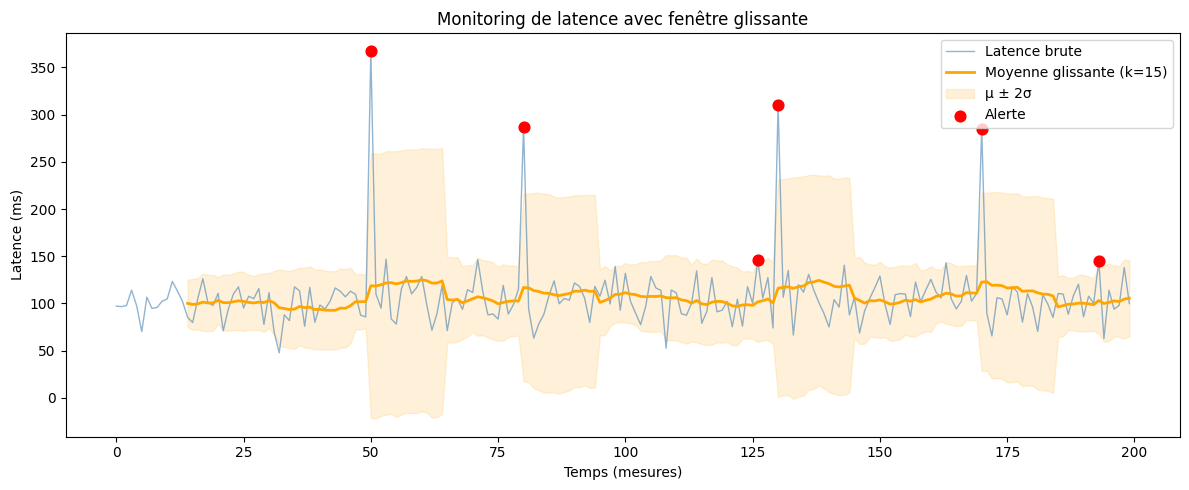

Alertes déclenchées : 6 sur 200 mesures


In [11]:
from collections import deque
import random
import matplotlib.pyplot as plt

# Simulation : flux de mesures de latence (ms)
random.seed(42)
N = 200
latencies = [random.gauss(100, 20) for _ in range(N)]
# Injection de quelques pics
for i in [50, 80, 130, 170]:
    latencies[i] = random.gauss(300, 30)

WINDOW = 15  # taille de la fenêtre glissante

window    = deque(maxlen=WINDOW)
means, stds, alerts = [], [], []

for i, lat in enumerate(latencies):
    window.append(lat)
    if len(window) == WINDOW:
        import statistics
        mu  = statistics.mean(window)
        std = statistics.stdev(window)
        means.append(mu)
        stds.append(std)
        # Alerte si la valeur courante dépasse µ + 2σ
        alerts.append(lat > mu + 2 * std)
    else:
        means.append(None)
        stds.append(None)
        alerts.append(False)

# Graphique
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(latencies, color='steelblue', alpha=0.6, label='Latence brute', linewidth=1)

valid = [(i, m, s) for i, (m, s) in enumerate(zip(means, stds)) if m is not None]
xs = [v[0] for v in valid]
ms = [v[1] for v in valid]
ss = [v[2] for v in valid]

ax.plot(xs, ms, color='orange', linewidth=2, label=f'Moyenne glissante (k={WINDOW})')
ax.fill_between(xs,
                [m - 2*s for m, s in zip(ms, ss)],
                [m + 2*s for m, s in zip(ms, ss)],
                alpha=0.15, color='orange', label='µ ± 2σ')

alert_idx = [i for i, a in enumerate(alerts) if a]
ax.scatter(alert_idx, [latencies[i] for i in alert_idx],
           color='red', zorder=5, s=60, label='Alerte')

ax.set_xlabel('Temps (mesures)')
ax.set_ylabel('Latence (ms)')
ax.set_title('Monitoring de latence avec fenêtre glissante')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Alertes déclenchées : {sum(alerts)} sur {N} mesures")

## 6.2 Mini-projet : Pipeline FIFO de traitement de logs

Voici l’énoncé d’un mini-projet qui vous entraînera à utiliser une structure vue (file/queue/FIFO) en se mettant dans le contexte d’un pipeline.

### Contexte

Un serveur web génère un flux continu de logs (requêtes HTTP). Un pipeline de traitement
doit les consommer **dans l'ordre d'arrivée** (FIFO) et produire des statistiques en temps réel :
taux d'erreur sur les 60 dernières secondes, débit moyen, top des endpoints les plus sollicités.

Ce modèle est directement transposable à **Kafka** (les topics sont des files FIFO distribuées)
ou **RabbitMQ** (queues de messages).

### Tâche

Implémenter la classe `LogPipeline` qui :
1. Reçoit des événements de log dans une file FIFO (`queue.Queue`)
2. Maintient une fenêtre glissante de 60 secondes pour le calcul du taux d'erreur
3. Expose des statistiques : `error_rate()`, `throughput()`, `top_endpoints(k)`

On vous fournit aussi le code pour visualiser le pipeline

> **Note :** les files de **priorité** (pour traiter les ERRORs en premier) sont abordées
> dans le **Notebook C**, elles s'appuient sur la structure de tas (Heap).



In [12]:
import queue
import threading
import time
import random
from collections import deque, Counter
from dataclasses import dataclass


@dataclass
class LogEvent:
    """Un événement de log HTTP."""
    timestamp: float
    method: str       # GET, POST, ...
    endpoint: str     # /api/users, /api/orders, ...
    status_code: int  # 200, 404, 500, ...
    duration_ms: float

    @property
    def is_error(self) -> bool:
        return self.status_code >= 400

    def __str__(self):
        return f"{self.method} {self.endpoint} → {self.status_code} ({self.duration_ms:.1f}ms)"


class LogPipeline:
    """Pipeline FIFO de traitement de logs avec fenêtre glissante."""

    def __init__(self, window_seconds: int = 60):
        self._queue = queue.Queue()          # file FIFO thread-safe
        self._window = deque()               # fenêtre glissante (timestamp, is_error)
        self._window_sec = window_seconds
        self._endpoint_counter = Counter()   # comptage des endpoints
        self._processed = 0
        self._running = False

    # ── Producteur ────────────────────────────────────────────────

    def push(self, event: LogEvent) -> None:
        """Enfile un événement. O(1). Appelé par le producteur."""
        self._queue.put(event)

    # ── Consommateur ──────────────────────────────────────────────

    def _consume(self) -> None:
        """Boucle consommateur : traite les événements dans l'ordre FIFO."""
        while self._running:
            try:
                event = self._queue.get(timeout=0.1)
            except queue.Empty:
                continue
            self._process(event)
            self._queue.task_done()

    def _process(self, event: LogEvent) -> None:
        """Traite un événement : mise à jour de la fenêtre et des compteurs."""
        now = event.timestamp
        # Ajouter à la fenêtre glissante
        self._window.append((now, event.is_error))
        # Éjecter les entrées trop vieilles
        while self._window and now - self._window[0][0] > self._window_sec:
            self._window.popleft()
        # Comptage endpoints
        self._endpoint_counter[event.endpoint] += 1
        self._processed += 1

    # ── Statistiques ──────────────────────────────────────────────

    def error_rate(self) -> float:
        """Taux d'erreur dans la fenêtre glissante. O(1)."""
        if not self._window:
            return 0.0
        errors = sum(1 for _, is_err in self._window if is_err)
        return errors / len(self._window)

    def throughput(self) -> float:
        """Débit : événements / seconde dans la fenêtre. O(1)."""
        if len(self._window) < 2:
            return 0.0
        elapsed = self._window[-1][0] - self._window[0][0]
        return len(self._window) / elapsed if elapsed > 0 else 0.0

    def top_endpoints(self, k: int = 5) -> list[tuple[str, int]]:
        """Top-k endpoints les plus sollicités. O(n)."""
        return self._endpoint_counter.most_common(k)

    # ── Cycle de vie ──────────────────────────────────────────────

    def start(self):
        self._running = True
        self._thread = threading.Thread(target=self._consume, daemon=True)
        self._thread.start()

    def stop(self):
        self._running = False
        self._thread.join(timeout=2)


# ── Simulation ────────────────────────────────────────────────────

ENDPOINTS = ['/api/users', '/api/orders', '/api/products', '/api/search', '/health']
METHODS   = ['GET', 'POST', 'DELETE']

def generate_event(t: float) -> LogEvent:
    """Génère un événement de log aléatoire."""
    status = random.choices(
        [200, 201, 404, 500],
        weights=[70, 15, 10, 5]
    )[0]
    return LogEvent(
        timestamp=t,
        method=random.choice(METHODS),
        endpoint=random.choice(ENDPOINTS),
        status_code=status,
        duration_ms=random.gauss(80, 20)
    )


# Lancer le pipeline
pipeline = LogPipeline(window_seconds=60)
pipeline.start()

# Injecter 200 événements sur une plage de 90 secondes simulées
random.seed(42)
t0 = time.time()
events = [generate_event(t0 + random.uniform(0, 90)) for _ in range(200)]
events.sort(key=lambda e: e.timestamp)  # tri chronologique (FIFO)

for event in events:
    pipeline.push(event)

pipeline._queue.join()  # attendre que tout soit traité
pipeline.stop()

print(f"Événements traités   : {pipeline._processed}")
print(f"Taux d'erreur (fen.) : {pipeline.error_rate():.1%}")
print(f"Débit (fen.)         : {pipeline.throughput():.1f} req/s")
print(f"\nTop 5 endpoints :")
for endpoint, count in pipeline.top_endpoints(5):
    print(f"  {endpoint:<20} {count} requêtes")


Événements traités   : 200
Taux d'erreur (fen.) : 18.7%
Débit (fen.)         : 2.3 req/s

Top 5 endpoints :
  /api/orders          47 requêtes
  /api/users           41 requêtes
  /api/products        41 requêtes
  /api/search          38 requêtes
  /health              33 requêtes


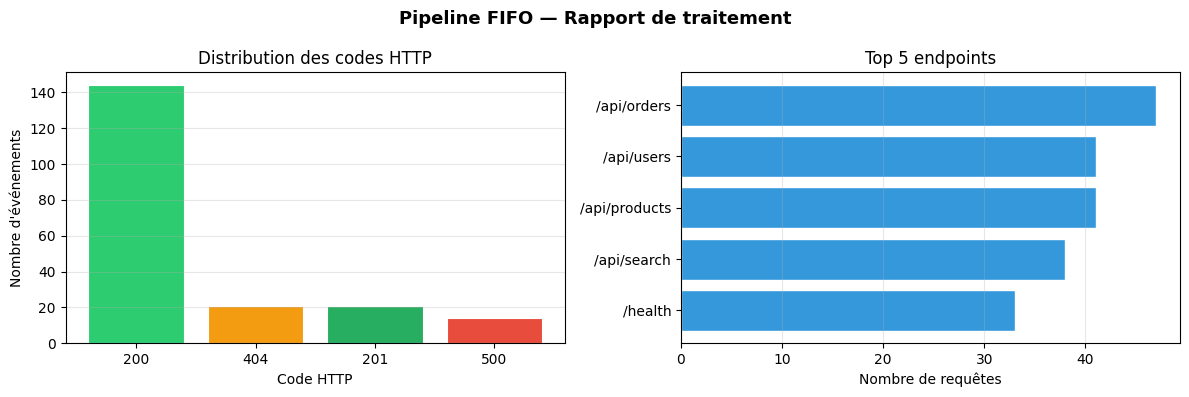


Modèle producteur/consommateur FIFO → transposable à Kafka (topics) ou RabbitMQ (queues).
Les files de priorité (ERRORs en premier) → voir Notebook C (Heap).


In [13]:
# Visualisation du pipeline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Graphique 1 : distribution des codes HTTP ──────────────────────
status_counts = Counter(e.status_code for e in events)
colors_map = {200: '#2ecc71', 201: '#27ae60', 404: '#f39c12', 500: '#e74c3c'}
labels = [str(k) for k in status_counts.keys()]
values = list(status_counts.values())
bar_colors = [colors_map.get(k, '#95a5a6') for k in status_counts.keys()]

axes[0].bar(labels, values, color=bar_colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribution des codes HTTP')
axes[0].set_xlabel('Code HTTP')
axes[0].set_ylabel('Nombre d\'événements')
axes[0].grid(axis='y', alpha=0.3)

# ── Graphique 2 : top endpoints ────────────────────────────────────
top = pipeline.top_endpoints(5)
ep_labels = [ep for ep, _ in top]
ep_values = [cnt for _, cnt in top]

axes[1].barh(ep_labels, ep_values, color='#3498db', edgecolor='white')
axes[1].set_title('Top 5 endpoints')
axes[1].set_xlabel('Nombre de requêtes')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Pipeline FIFO - Rapport de traitement', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nModèle producteur/consommateur FIFO → transposable à Kafka (topics) ou RabbitMQ (queues).")
print("Les files de priorité (ERRORs en premier) → voir Notebook C (Heap).")


# Conclusion

## Réflexe à développer

> Avant de choisir une structure de données, poser deux questions :  
> **Quelle opération sera la plus fréquente ?** (insertion, recherche, suppression)  
> **Quel est le pattern d'accès ?** (LIFO → Stack, FIFO → Queue, aléatoire → tableau/dict)

## Pour aller plus loin : Mini-mémoire

*Ces éléments ne sont pas traités dans ce notebook. Ils constituent des pistes d'approfondissement pour les étudiants qui travaillent sur un mini-mémoire en lien avec cette séance, ou qui souhaitent appronfondir ce sujet.*

- **Sujet 1, Tables de hachage** : analyse approfondie de l'implémentation CPython de `dict` (`__hash__`, `__eq__`), benchmark du facteur de charge, comparaison chaînage vs open addressing
- **Sujet 2, Index BDD et B-tree** : lien entre liste chaînée et B+ tree (feuilles chaînées), implémentation AVL with rotations, benchmark PostgreSQL EXPLAIN ANALYZE
- **Sujet 6, Tri avancé et Map/Reduce** : tri externe sur fichier 500 Mo (chunks triés + fusion par Heap), lien Mergesort ↔ Map/Reduce distribué
- **File de priorité (Heap)** : pour les files qui traitent les événements critiques en premier (voir **Notebook C**)
